# IEMOCAP Data Analysis

Notebook này chỉ dùng để phân tích dữ liệu `AbstractTTS/IEMOCAP` và xem từng sample. Không load model/checkpoint.

In [7]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Audio, display

from dataset import CANONICAL_LABELS, load_iemocap_splits
from features import describe_acoustic_cues, extract_acoustic_features

## 1. Load config và dataset

In [8]:
CONFIG_PATH = Path("config.yaml")

with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

sampling_rate = int(config.get("audio", {}).get("sampling_rate", 16000))
datasets = load_iemocap_splits(config)

print("sampling_rate:", sampling_rate)
for split, ds in datasets.items():
    print(split, len(ds), ds.column_names)

sampling_rate: 16000
train 7835 ['input_values', 'labels', 'emotion', 'transcript', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
validation 979 ['input_values', 'labels', 'emotion', 'transcript', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
test 980 ['input_values', 'labels', 'emotion', 'transcript', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']


In [9]:
import re

def parse_iemocap_id(utt_id: str):
    """
    Example:
    Ses01F_impro01_F000
    Ses02M_script03_1_M012
    """

    # Lấy session: Ses01, Ses02...
    m = re.search(r"(Ses\d{2})", utt_id)
    if not m:
        raise ValueError(f"Cannot parse session from: {utt_id}")
    session_id = m.group(1)

    parts = utt_id.split("_")

    # Speaker role thường nằm ở token cuối: F000 hoặc M012
    last = parts[-1]
    speaker_role = last[0]  # F or M

    if speaker_role not in ["F", "M"]:
        raise ValueError(f"Cannot parse speaker from: {utt_id}")

    # turn index
    turn_index = int(re.sub(r"\D", "", last))

    # dialogue id = bỏ phần utterance cuối
    dialogue_id = "_".join(parts[:-1])

    speaker_id = f"{session_id}_{speaker_role}"

    return {
        "session_id": session_id,
        "dialogue_id": dialogue_id,
        "speaker_role": speaker_role,
        "speaker_id": speaker_id,
        "turn_index": turn_index,
    }

## 2. Tổng quan phân bố label

In [10]:
summary_rows = []
for split, ds in datasets.items():
    counts = Counter(ds["emotion"])
    total = len(ds)
    for label in CANONICAL_LABELS:
        summary_rows.append(
            {
                "split": split,
                "emotion": label,
                "count": counts.get(label, 0),
                "ratio": counts.get(label, 0) / total if total else 0.0,
            }
        )

label_df = pd.DataFrame(summary_rows)
label_df

,split,emotion,count,ratio
0,train,neutral,1393,0.177792
1,train,happy,2081,0.265603
2,train,sad,994,0.126867
3,train,angry,3367,0.429738
4,validation,neutral,174,0.177732
5,validation,happy,282,0.288049
6,validation,sad,120,0.122574
7,validation,angry,403,0.411645
8,test,neutral,159,0.162245
9,test,happy,269,0.274490


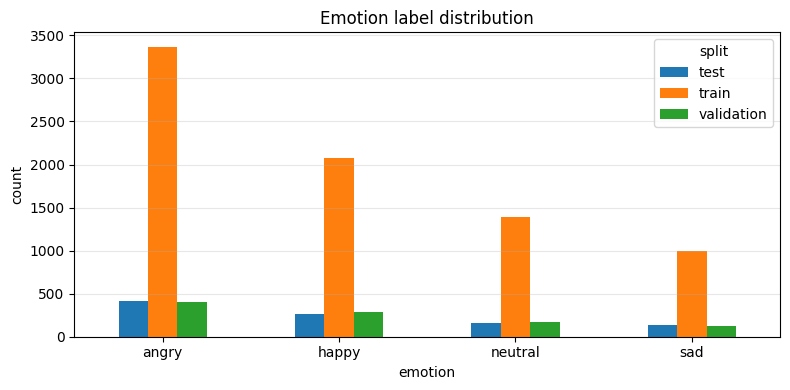

In [11]:
pivot = label_df.pivot(index="emotion", columns="split", values="count").fillna(0)
ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Emotion label distribution")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 3. Tạo bảng metadata để scan nhanh

In [12]:
def build_metadata(split):
    rows = []
    ds = datasets[split]
    for idx, row in enumerate(ds):
        waveform = np.asarray(row["input_values"], dtype=np.float32)
        rows.append(
            {
                "split": split,
                "index": idx,
                "emotion": row["emotion"],
                "duration": len(waveform) / sampling_rate,
                "transcript": row.get("transcript", ""),
                "speaking_rate": row.get("speaking_rate"),
                "pitch_mean": row.get("pitch_mean"),
                "pitch_std": row.get("pitch_std"),
                "rms": row.get("rms"),
                "relative_db": row.get("relative_db"),
            }
        )
    return pd.DataFrame(rows)

metadata = pd.concat([build_metadata(split) for split in datasets.keys()], ignore_index=True)
metadata.head()

,split,index,emotion,duration,transcript,speaking_rate,pitch_mean,pitch_std,rms,relative_db
0,train,0,neutral,10.639938,"I mean, you know, you're going to have at lea...",10.62,120.037918,24.471964,0.012046,-15.963955
1,train,1,neutral,4.680063,Don't you guys have access to computers over ...,8.97,136.607330,23.832935,0.009494,-12.687503
2,train,2,angry,9.090000,Pass what up? I mean these fish swim out of ...,10.12,252.868759,76.415627,0.048823,-15.578699
3,train,3,angry,1.300000,Clearly.,4.62,123.889168,32.538727,0.012765,-23.654795
4,train,4,happy,2.819937,Yeah. Think about that.,5.67,172.457657,52.530113,0.030412,-11.960638


## 4. Thống kê duration và acoustic cues

In [13]:
metadata.groupby(["split", "emotion"])[["duration", "speaking_rate", "pitch_mean", "pitch_std", "rms", "relative_db"]].describe().round(3)

duration                                                  \
                      count   mean    std    min    25%    50%    75%   max   
split      emotion                                                            
test       angry      416.0  4.458  2.604  0.860  2.490  3.800  5.591  12.0   
           happy      269.0  4.378  2.563  0.920  2.441  3.699  5.920  12.0   
           neutral    159.0  3.849  2.271  0.732  2.044  3.396  4.935  12.0   
           sad        136.0  5.178  3.270  1.150  2.632  4.185  7.380  12.0   
train      angry     3367.0  4.448  2.708  0.670  2.428  3.592  5.841  12.0   
           happy     2081.0  4.382  2.741  0.585  2.327  3.554  5.757  12.0   
           neutral   1393.0  3.869  2.440  0.730  2.110  3.130  4.917  12.0   
           sad        994.0  5.000  3.148  0.764  2.529  3.962  6.664  12.0   
validation angry      403.0  4.333  2.545  0.811  2.475  3.530  5.556  12.0   
           happy      282.0  4.195  2.563  0.956  2.366  3.420  5.307  12.0   
           neutral    174.0  3.845  2.443  0.867  2.099  3.050  4.917  12.0   
           sad        120.0  5.386  3.259  1.320  2.896  4.475  6.960  12.0   

                   speaking_rate          ...    rms        relative_db  \
                           count    mean  ...    75%    max       count   
split      emotion                        ...                             
test       angry           416.0  10.146  ...  0.029  0.198       416.0   
           happy           269.0   9.641  ...  0.027  0.115       269.0   
           neutral         159.0   8.776  ...  0.017  0.105       159.0   
           sad             136.0   7.902  ...  0.009  0.046       136.0   
train      angry          3367.0  10.098  ...  0.030  0.482      3367.0   
           happy          2081.0   9.332  ...  0.026  0.368      2081.0   
           neutral        1393.0   9.361  ...  0.016  0.105      1393.0   
           sad             994.0   7.442  ...  0.009  0.099       994.0   
validation angry           403.0  10.298  ...  0.030  0.279       403.0   
           happy           282.0   9.527  ...  0.028  0.248       282.0   
           neutral         174.0   9.257  ...  0.016  0.044       174.0   
           sad             120.0   7.904  ...  0.009  0.034       120.0   

                                                                          
                      mean    std     min     25%     50%     75%    max  
split      emotion                                                        
test       angry   -15.889  4.178 -29.425 -18.692 -15.663 -12.853 -4.875  
           happy   -15.172  4.129 -29.052 -17.976 -14.908 -11.994 -6.217  
           neutral -14.153  3.980 -25.380 -16.806 -13.987 -11.831 -4.263  
           sad     -15.029  4.289 -25.098 -17.707 -15.051 -12.287 -4.354  
train      angry   -15.994  4.229 -33.318 -18.632 -15.746 -13.044 -4.417  
           happy   -15.155  4.054 -34.411 -17.705 -14.992 -12.471 -3.086  
           neutral -14.168  3.663 -28.941 -16.572 -14.052 -11.652 -2.611  
           sad     -14.567  4.035 -30.444 -17.288 -14.401 -11.846 -2.230  
validation angry   -16.163  4.509 -30.780 -18.466 -15.591 -12.990 -6.210  
           happy   -14.770  4.218 -32.352 -17.233 -14.819 -11.823 -3.256  
           neutral -14.783  4.036 -26.346 -17.159 -14.697 -11.855 -6.807  
           sad     -14.767  3.822 -24.678 -17.073 -14.700 -12.029 -5.766  

[12 rows x 48 columns]

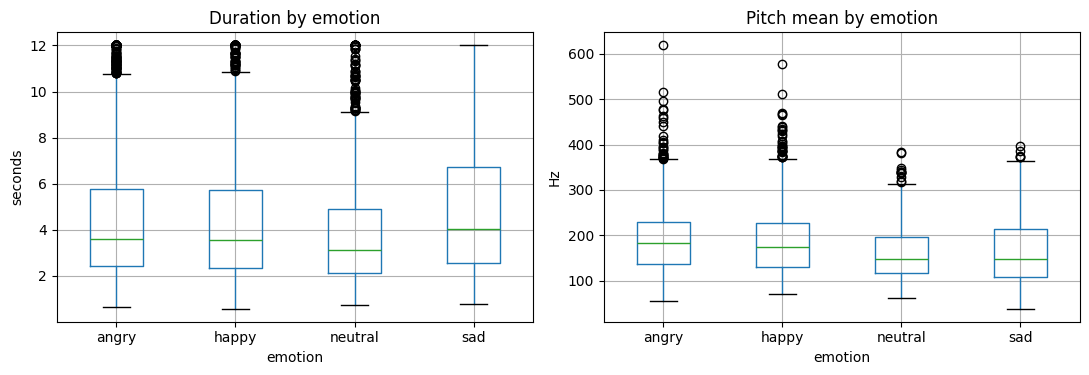

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metadata.boxplot(column="duration", by="emotion", ax=axes[0])
axes[0].set_title("Duration by emotion")
axes[0].set_xlabel("emotion")
axes[0].set_ylabel("seconds")

metadata.boxplot(column="pitch_mean", by="emotion", ax=axes[1])
axes[1].set_title("Pitch mean by emotion")
axes[1].set_xlabel("emotion")
axes[1].set_ylabel("Hz")

plt.suptitle("")
plt.tight_layout()

## 5. Xem sample theo split/index

split: train
index: 0
emotion: neutral
label_id: 0
duration: 10.64 seconds
transcript:  I mean, you know, you're going to have at least, like, two hundred and fifty people come.  So we're going to need, you know, just a huge buffet.
acoustic cues: pitch_mean=120.0Hz, pitch_std=24.5, rms=0.0120, duration=10.64s, speech_rate=10.62 words/s
raw cues: {'duration': 10.6399375, 'energy': 0.00025556021137163043, 'rms': 0.012046324089169502, 'relative_db': -15.96395492553711, 'pitch_mean': 120.03791809082031, 'pitch_std': 24.47196388244629, 'speech_rate': 10.619999885559082}


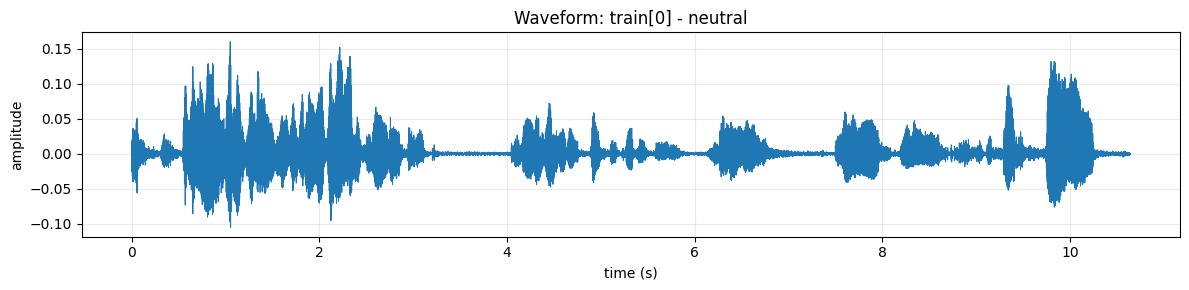

In [15]:
def show_sample(split="train", index=0, play_audio=True):
    row = datasets[split][index]
    waveform = np.asarray(row["input_values"], dtype=np.float32)
    transcript = row.get("transcript", "")
    cues = extract_acoustic_features(waveform, sampling_rate, transcript=transcript, dataset_row=row)

    print("split:", split)
    print("index:", index)
    print("emotion:", row["emotion"])
    print("label_id:", row["labels"])
    print("duration:", round(len(waveform) / sampling_rate, 3), "seconds")
    print("transcript:", transcript)
    print("acoustic cues:", describe_acoustic_cues(cues))
    print("raw cues:", cues)

    if play_audio:
        display(Audio(waveform, rate=sampling_rate))

    fig, ax = plt.subplots(figsize=(12, 3))
    t = np.arange(len(waveform)) / sampling_rate
    ax.plot(t, waveform, linewidth=0.7)
    ax.set_title(f"Waveform: {split}[{index}] - {row['emotion']}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("amplitude")
    ax.grid(alpha=0.25)
    plt.tight_layout()

    return row

row = show_sample("train", 0, play_audio=True)

## 6. Xem sample theo emotion

In [16]:
def list_samples(split="train", emotion=None, n=10, sort_by="index", ascending=True):
    df = metadata[metadata["split"] == split].copy()
    if emotion is not None:
        df = df[df["emotion"] == emotion]
    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)
    return df.head(n)[["split", "index", "emotion", "duration", "transcript", "speaking_rate", "pitch_mean", "rms"]]

list_samples(split="train", emotion="sad", n=10)

,split,index,emotion,duration,transcript,speaking_rate,pitch_mean,rms
9,train,9,sad,3.066500,I ah--,0.98,111.657326,0.003503
17,train,17,sad,7.861000,You know I was always the one to tell him to ...,7.12,108.330788,0.004017
18,train,18,sad,1.865000,"Yeah, and uh--",4.29,213.560806,0.008655
22,train,22,sad,4.939938,Mm hmm. We'll build a bunker and never come ...,8.10,209.859528,0.012841
24,train,24,sad,2.349937,Just about all.,5.11,95.086113,0.002867
38,train,38,sad,2.078500,"You gotta take care of our baby for me, alright?",18.76,93.321014,0.007505
61,train,61,sad,2.014750,Yes.,1.49,102.410347,0.001012
67,train,67,sad,4.409937,"I'm gonna be in Bagdad, just doing security.",9.07,111.789864,0.008767
80,train,80,sad,2.109938,Nobody's ever gonna forget him.,12.32,275.539215,0.018385
82,train,82,sad,9.730000,Well I can't be okay with it the same way you...,7.71,98.152740,0.004095


split: train
index: 111
emotion: sad
label_id: 2
duration: 12.0 seconds
transcript:  It's not fair but I mean that's, you know, the course of life is that, you know, you meet people and you lose them.
acoustic cues: pitch_mean=93.4Hz, pitch_std=11.7, rms=0.0035, duration=12.00s, speech_rate=7.23 words/s
raw cues: {'duration': 12.0, 'energy': 2.388378925388679e-05, 'rms': 0.0035081503447145224, 'relative_db': -17.78803062438965, 'pitch_mean': 93.39493560791016, 'pitch_std': 11.65927791595459, 'speech_rate': 7.230000019073486}


{'input_values': [0.002288818359375,
  0.002960205078125,
  0.003326416015625,
  0.002716064453125,
  0.002899169921875,
  0.002838134765625,
  0.001556396484375,
  0.001953125,
  0.002716064453125,
  0.002838134765625,
  0.003570556640625,
  0.003875732421875,
  0.002838134765625,
  -0.00018310546875,
  -0.00341796875,
  -0.003997802734375,
  -0.003143310546875,
  -0.0035400390625,
  -0.004180908203125,
  -0.0037841796875,
  -0.00372314453125,
  -0.003814697265625,
  -0.004547119140625,
  -0.00531005859375,
  -0.003265380859375,
  -0.000274658203125,
  0.000640869140625,
  0.00115966796875,
  0.001373291015625,
  0.0008544921875,
  0.00103759765625,
  3.0517578125e-05,
  -0.001129150390625,
  0.000152587890625,
  0.001922607421875,
  0.00244140625,
  0.0030517578125,
  0.003173828125,
  0.002227783203125,
  0.00244140625,
  0.0020751953125,
  0.00018310546875,
  0.000152587890625,
  0.000518798828125,
  0.0008544921875,
  0.0028076171875,
  0.002349853515625,
  0.000457763671875,
  0.

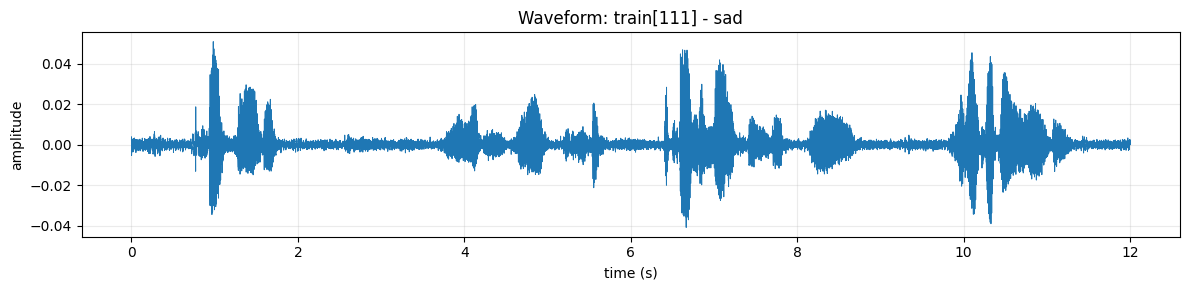

In [17]:
# Sau khi xem bảng trên, lấy index mong muốn và gọi show_sample.
show_sample("train", int(list_samples(split="train", emotion="sad", n=18).iloc[16]["index"]), play_audio=True)

## 7. Xem các sample dài/ngắn hoặc cue cực trị

In [18]:
metadata.sort_values("duration", ascending=False).head(10)[["split", "index", "emotion", "duration", "transcript"]]

,split,index,emotion,duration,transcript
3277,train,3277,angry,12.0,it's just like nobody- nobody wants to hire m...
2528,train,2528,angry,12.0,"When I think of a family, when I think of my ..."
7296,train,7296,angry,12.0,Yes! I like it an hour a day. If I had to g...
892,train,892,angry,12.0,And I had this idea as I was watching them go...
7330,train,7330,happy,12.0,They don't know what drives them. They don't...
7337,train,7337,sad,12.0,"You know, he was gonna, and we -- all the way..."
3475,train,3475,angry,12.0,"No, we won't. It's pointless. It's like wai..."
7381,train,7381,angry,12.0,Everybody's told the same story. It keeps us...
3452,train,3452,happy,12.0,I don't know what to say. I have no imaginat...
3441,train,3441,sad,12.0,I guess we saw it coming and she lasted a lot...


In [19]:
metadata.sort_values("pitch_mean", ascending=False).head(10)[["split", "index", "emotion", "pitch_mean", "pitch_std", "transcript"]]

,split,index,emotion,pitch_mean,pitch_std,transcript
957,train,957,angry,618.340271,5.754841,What?
6354,train,6354,happy,577.466858,177.057999,Look.
646,train,646,angry,515.047485,107.383080,Swine.
1908,train,1908,happy,512.204041,213.338928,What? Oh my god.
8159,validation,324,angry,495.200928,189.623978,Marry you again? Huh.
5003,train,5003,angry,477.373505,192.621246,Are you crazy?
4358,train,4358,angry,475.200134,191.916885,What? There- There's hundreds of thousands of...
1700,train,1700,happy,469.909332,117.838509,She calls you Barry?
2185,train,2185,happy,468.169098,205.554367,"You did? Oh, my Gosh, I'm so proud of you."
1256,train,1256,happy,465.850220,188.856903,"Well, that's serious enough isn't it?"


In [20]:
metadata.sort_values("rms", ascending=False).head(10)[["split", "index", "emotion", "rms", "relative_db", "transcript"]]

,split,index,emotion,rms,relative_db,transcript
4930,train,4930,angry,0.481559,-6.529294,Shut up. Shut up. I wouldn't marry you again ...
2476,train,2476,angry,0.426918,-10.832250,Oh yes I am...Oh yes I am. Let go of me. You ...
5955,train,5955,angry,0.372053,-10.072449,"Shut up. Shut up. God, I wouldn't marry you a..."
5239,train,5239,happy,0.368245,-13.067596,[LAUGHTER] Why did she pick you? Where were you?
5245,train,5245,angry,0.347105,-13.085434,Yes I am. Stop it. Stop it. Let go of me. ...
5579,train,5579,angry,0.322137,-10.452421,You above all have got to believe. Just don't...
76,train,76,angry,0.321500,-13.416797,"Oh you're cruel you're...you're...I hate you,..."
7167,train,7167,angry,0.296426,-13.220180,"You are a vile, ill-tempered, loose living, w..."
1356,train,1356,angry,0.291793,-13.920906,Stop it. No. Go away.
3940,train,3940,angry,0.282107,-18.116707,"I don't care. I don't care, do you understan..."


## 8. Random sample browser

split: validation
index: 87
emotion: sad
label_id: 2
duration: 2.32 seconds
transcript:  Yeah.
acoustic cues: pitch_mean=80.0Hz, pitch_std=4.0, rms=0.0016, duration=2.32s, speech_rate=0.86 words/s
raw cues: {'duration': 2.3199375, 'energy': 5.605065325653413e-06, 'rms': 0.0016376079292967916, 'relative_db': -15.282923698425293, 'pitch_mean': 80.0176010131836, 'pitch_std': 4.040591239929199, 'speech_rate': 0.8600000143051147}


{'input_values': [0.0018310546875,
  0.001800537109375,
  0.0015869140625,
  0.001373291015625,
  0.000946044921875,
  0.000213623046875,
  -0.000274658203125,
  -0.000213623046875,
  -0.0001220703125,
  -0.000152587890625,
  -0.0001220703125,
  -6.103515625e-05,
  6.103515625e-05,
  0.0001220703125,
  -3.0517578125e-05,
  -0.000244140625,
  -0.00018310546875,
  -9.1552734375e-05,
  0.0,
  0.00018310546875,
  0.000152587890625,
  -6.103515625e-05,
  -0.000396728515625,
  -0.000762939453125,
  -0.000946044921875,
  -0.00091552734375,
  -0.0008544921875,
  -0.000823974609375,
  -0.000732421875,
  -0.00091552734375,
  -0.0013427734375,
  -0.001373291015625,
  -0.001190185546875,
  -0.001007080078125,
  -0.000762939453125,
  -0.000762939453125,
  -0.000762939453125,
  -0.00067138671875,
  -0.000579833984375,
  -0.000335693359375,
  -0.000396728515625,
  -0.000579833984375,
  -0.000396728515625,
  -0.0003662109375,
  -0.000274658203125,
  6.103515625e-05,
  -6.103515625e-05,
  -0.0002441406

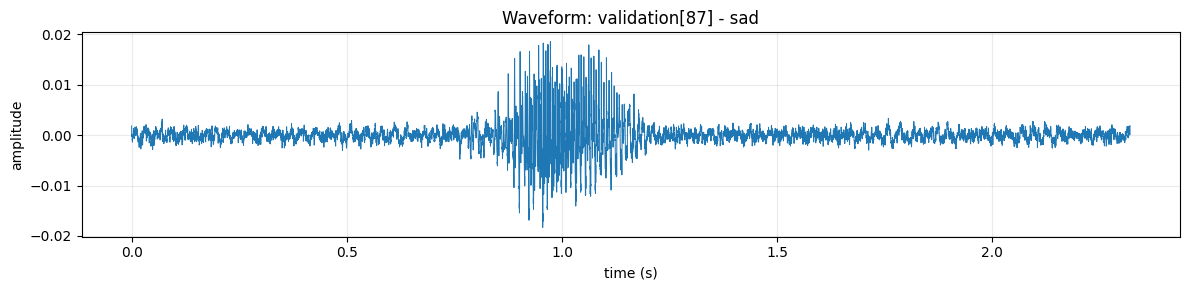

In [21]:
def random_sample(split="train", emotion=None, seed=None, play_audio=True):
    rng = np.random.default_rng(seed)
    df = metadata[metadata["split"] == split]
    if emotion is not None:
        df = df[df["emotion"] == emotion]
    if len(df) == 0:
        raise ValueError("No samples match the query.")
    chosen = df.iloc[int(rng.integers(0, len(df)))]
    return show_sample(split, int(chosen["index"]), play_audio=play_audio)

random_sample(split="validation", emotion=None, seed=42, play_audio=True)